# Advanced Data Analysis and Visualization in Logistics

Week 3 logistics analytics project using Python.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('Week2_Logistics_Cleaned_Data.csv')
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df.head()

,Shipment_ID,Order_Date,Shipping_Mode,Region,Market,Product_Category,Priority,Distance_km,Shipment_Weight_kg,Order_Quantity,Scheduled_Days,Actual_Delivery_Days,Shipping_Cost,Sales_Value,Delay_Days,On_Time,Cost_per_Unit
0,SHP100000,2017-01-01 00:00:00.000000000,Second Class,South America,LATAM,Technology,Critical,1104.97,14.48,1,3,4,100.180,159.44,1,0,100.180000
1,SHP100001,2017-01-01 04:22:55.887943971,Standard Class,Western Europe,LATAM,Clothing,Medium,707.31,10.00,3,4,4,79.800,357.00,0,1,26.600000
2,SHP100002,2017-01-01 08:45:51.775887943,Standard Class,Oceania,Africa,Office Supplies,High,657.17,18.20,3,4,4,84.650,192.87,0,1,28.216667
3,SHP100003,2017-01-01 13:08:47.663831915,Standard Class,South America,Pacific Asia,Clothing,High,657.17,7.30,3,4,5,59.370,375.83,1,0,19.790000
4,SHP100004,2017-01-01 17:31:43.551775887,Same Day,Eastern Asia,USCA,Sports,High,2084.19,12.47,3,1,3,172.335,439.99,2,0,57.445000


## 1. Dataset Overview

In [4]:
print('Shape:', df.shape)
print('\nMissing values:')
print(df.isna().sum())
print('\nExact duplicate rows:', df.duplicated().sum())
print('\nData types:')
print(df.dtypes)

Shape: (2001, 17)

Missing values:
Shipment_ID             0
Order_Date              0
Shipping_Mode           0
Region                  0
Market                  0
Product_Category        0
Priority                0
Distance_km             0
Shipment_Weight_kg      0
Order_Quantity          0
Scheduled_Days          0
Actual_Delivery_Days    0
Shipping_Cost           0
Sales_Value             0
Delay_Days              0
On_Time                 0
Cost_per_Unit           0
dtype: int64

Exact duplicate rows: 0

Data types:
Shipment_ID                     object
Order_Date              datetime64[ns]
Shipping_Mode                   object
Region                          object
Market                          object
Product_Category                object
Priority                        object
Distance_km                    float64
Shipment_Weight_kg             float64
Order_Quantity                   int64
Scheduled_Days                   int64
Actual_Delivery_Days             int64
Ship

## 2. Descriptive Statistics

In [5]:
num_cols = ['Distance_km','Shipment_Weight_kg','Order_Quantity','Scheduled_Days','Actual_Delivery_Days','Shipping_Cost','Sales_Value','Delay_Days','On_Time','Cost_per_Unit']
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Distance_km,2001.0,927.480240,574.364962,20.0000,485.26,811.270000,1226.400,2338.110
Shipment_Weight_kg,2001.0,14.030942,7.310748,1.4800,8.58,12.270000,17.950,32.005
Order_Quantity,2001.0,3.213393,1.528706,1.0000,2.00,3.000000,4.000,10.000
Scheduled_Days,2001.0,3.283358,0.933899,1.0000,3.00,4.000000,4.000,4.000
Actual_Delivery_Days,2001.0,3.767116,1.466199,1.0000,3.00,4.000000,5.000,8.000
Shipping_Cost,2001.0,94.046409,29.626042,23.4500,72.26,90.740000,112.290,172.335
Sales_Value,2001.0,344.415767,145.626496,72.3300,239.45,319.110000,423.130,957.980
Delay_Days,2001.0,0.717641,0.889794,0.0000,0.00,0.000000,1.000,5.000
On_Time,2001.0,0.522239,0.499630,0.0000,0.00,1.000000,1.000,1.000
Cost_per_Unit,2001.0,37.345204,24.782962,5.9775,20.97,30.416667,44.545,172.335


## 3. Delivery Performance

In [6]:
print(f"On-time rate: {df['On_Time'].mean():.1%}")
print(f"Delay rate: {(df['Delay_Days'] > 0).mean():.1%}")
print(f"Average delay among delayed shipments: {df.loc[df['Delay_Days'] > 0, 'Delay_Days'].mean():.2f} days")

On-time rate: 52.2%
Delay rate: 47.8%
Average delay among delayed shipments: 1.50 days


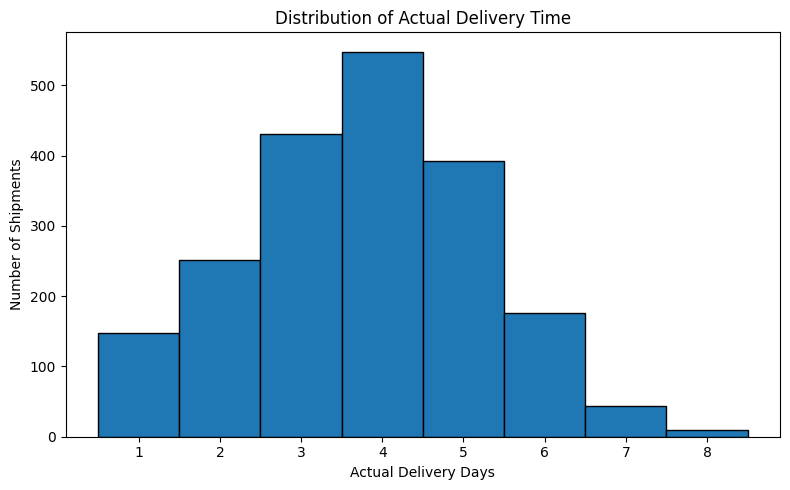

In [7]:
plt.figure(figsize=(8,5))
plt.hist(df['Actual_Delivery_Days'], bins=np.arange(0.5, 9.5, 1), edgecolor='black')
plt.xlabel('Actual Delivery Days'); plt.ylabel('Number of Shipments')
plt.title('Distribution of Actual Delivery Time')
plt.xticks(range(1,9)); plt.tight_layout(); plt.show()

## 4. Shipping Mode Analysis

In [8]:
mode = df.groupby('Shipping_Mode').agg(Shipments=('Shipment_ID','count'), On_Time_Rate=('On_Time','mean'), Avg_Delay=('Delay_Days','mean'), Avg_Cost=('Shipping_Cost','mean')).sort_values('On_Time_Rate', ascending=False)
mode

,Shipments,On_Time_Rate,Avg_Delay,Avg_Cost
Shipping_Mode,,,,
Standard Class,1130,0.538938,0.701770,85.831580
Same Day,113,0.530973,0.707965,129.145442
First Class,326,0.518405,0.696319,109.890475
Second Class,432,0.479167,0.777778,94.396875


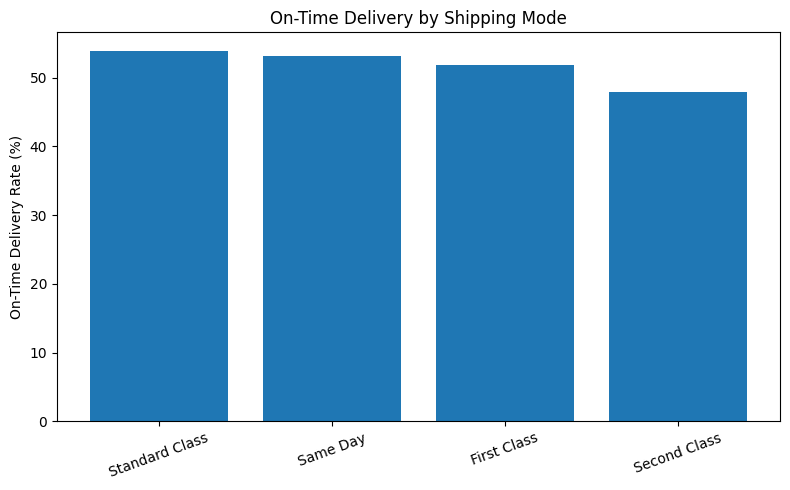

In [9]:
plt.figure(figsize=(8,5)); plt.bar(mode.index, mode['On_Time_Rate']*100)
plt.ylabel('On-Time Delivery Rate (%)'); plt.title('On-Time Delivery by Shipping Mode')
plt.xticks(rotation=20); plt.tight_layout(); plt.show()

## 5. Distance and Shipping Cost

Distance-cost correlation: 0.680


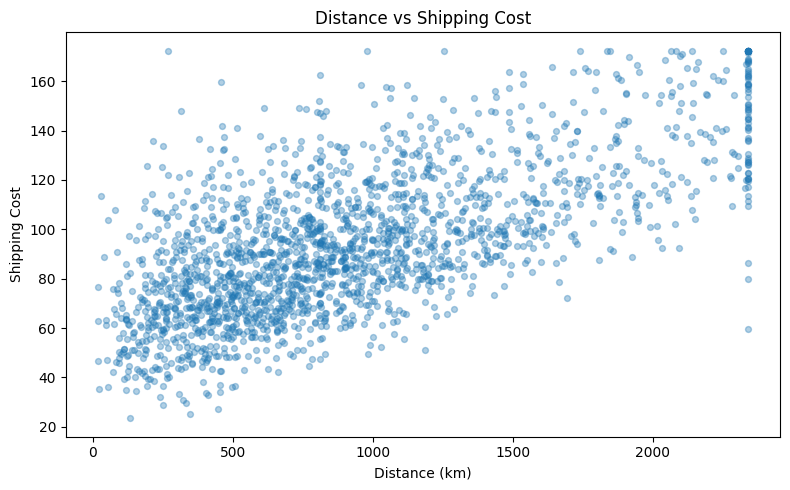

In [10]:
print(f"Distance-cost correlation: {df['Distance_km'].corr(df['Shipping_Cost']):.3f}")
plt.figure(figsize=(8,5)); plt.scatter(df['Distance_km'], df['Shipping_Cost'], alpha=0.35, s=18)
plt.xlabel('Distance (km)'); plt.ylabel('Shipping Cost'); plt.title('Distance vs Shipping Cost')
plt.tight_layout(); plt.show()

## 6. Regional Performance

In [11]:
region = df.groupby('Region').agg(Shipments=('Shipment_ID','count'), On_Time_Rate=('On_Time','mean'), Avg_Delay=('Delay_Days','mean'), Avg_Cost=('Shipping_Cost','mean')).sort_values('On_Time_Rate')
region

,Shipments,On_Time_Rate,Avg_Delay,Avg_Cost
Region,,,,
South America,334,0.488024,0.763473,92.783533
Western Europe,348,0.502874,0.784483,96.146422
Eastern Asia,313,0.527157,0.690096,94.089952
Central America,309,0.527508,0.679612,92.260000
Oceania,319,0.539185,0.708464,94.974138
USCA,378,0.547619,0.677249,93.870278


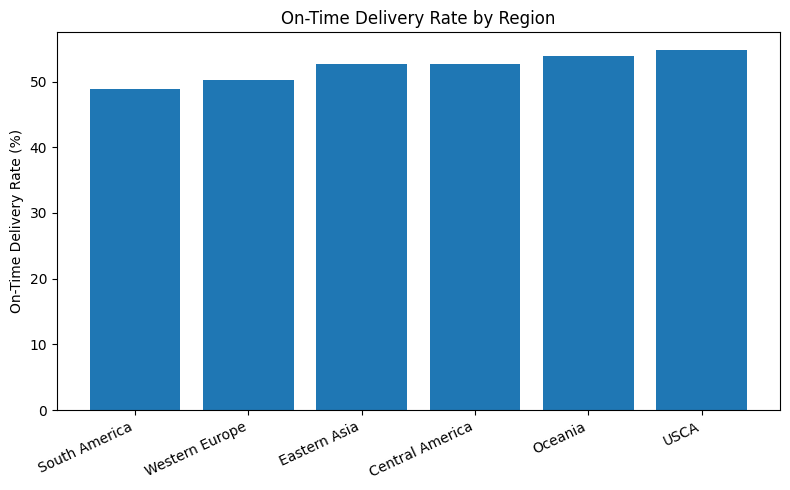

In [12]:
plt.figure(figsize=(8,5)); plt.bar(region.index, region['On_Time_Rate']*100)
plt.ylabel('On-Time Delivery Rate (%)'); plt.title('On-Time Delivery Rate by Region')
plt.xticks(rotation=25, ha='right'); plt.tight_layout(); plt.show()

## 7. Monthly Trend

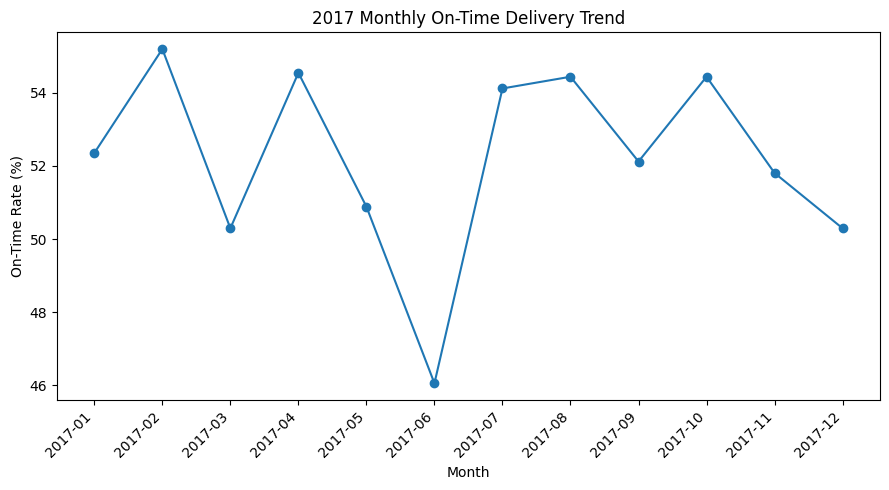

In [13]:
df['Year'] = df['Order_Date'].dt.year
df['Month'] = df['Order_Date'].dt.to_period('M').astype(str)
monthly = df[df['Year'] == 2017].groupby('Month')['On_Time'].mean()
plt.figure(figsize=(9,5)); plt.plot(monthly.index, monthly.values*100, marker='o')
plt.ylabel('On-Time Rate (%)'); plt.xlabel('Month'); plt.title('2017 Monthly On-Time Delivery Trend')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

## 8. Product Category Analysis

In [14]:
category = df.groupby('Product_Category').agg(Shipments=('Shipment_ID','count'), On_Time_Rate=('On_Time','mean'), Avg_Delay=('Delay_Days','mean'), Avg_Cost=('Shipping_Cost','mean'))
category

,Shipments,On_Time_Rate,Avg_Delay,Avg_Cost
Product_Category,,,,
Clothing,493,0.531440,0.730223,92.594959
Office Supplies,525,0.518095,0.706667,92.626638
Sports,498,0.506024,0.751004,96.068815
Technology,485,0.534021,0.682474,94.982052


### Product Category: Delivery Reliability vs Cost

This visualization compares delivery reliability with average shipping cost across product categories. It helps identify product categories that have relatively lower delivery reliability while also incurring higher transportation costs, highlighting potential areas for operational improvement.

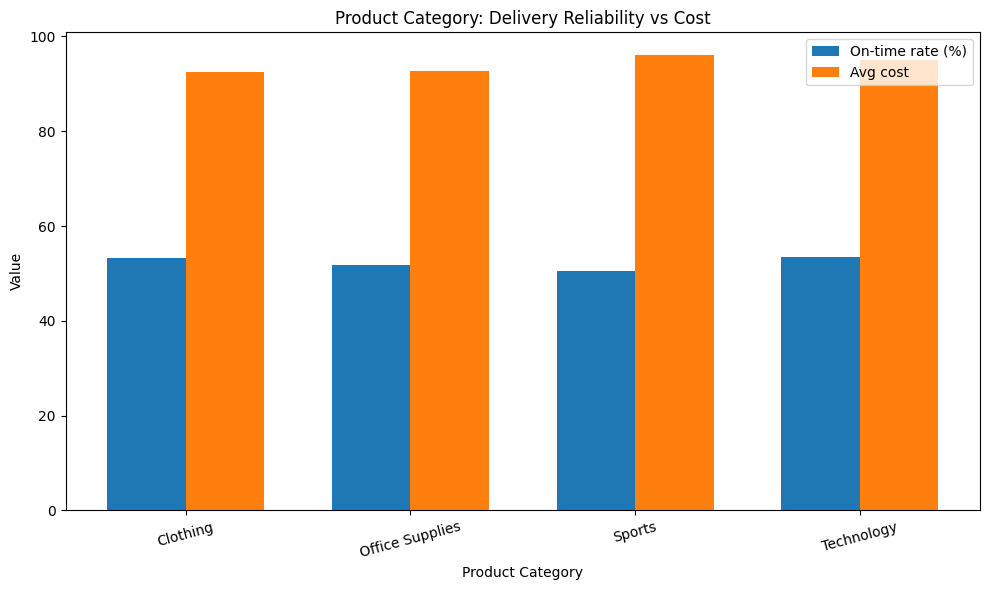

In [19]:
category = df.groupby('Product_Category').agg(
    On_Time_Rate=('On_Time', 'mean'),
    Avg_Cost=('Shipping_Cost', 'mean')
)

x = np.arange(len(category.index))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width/2,
    category['On_Time_Rate'] * 100,
    width,
    label='On-time rate (%)'
)

plt.bar(
    x + width/2,
    category['Avg_Cost'],
    width,
    label='Avg cost'
)

plt.xlabel('Product Category')
plt.ylabel('Value')
plt.title('Product Category: Delivery Reliability vs Cost')

plt.xticks(x, category.index, rotation=15)
plt.legend()

plt.tight_layout()
plt.show()

## 9. Correlation Analysis

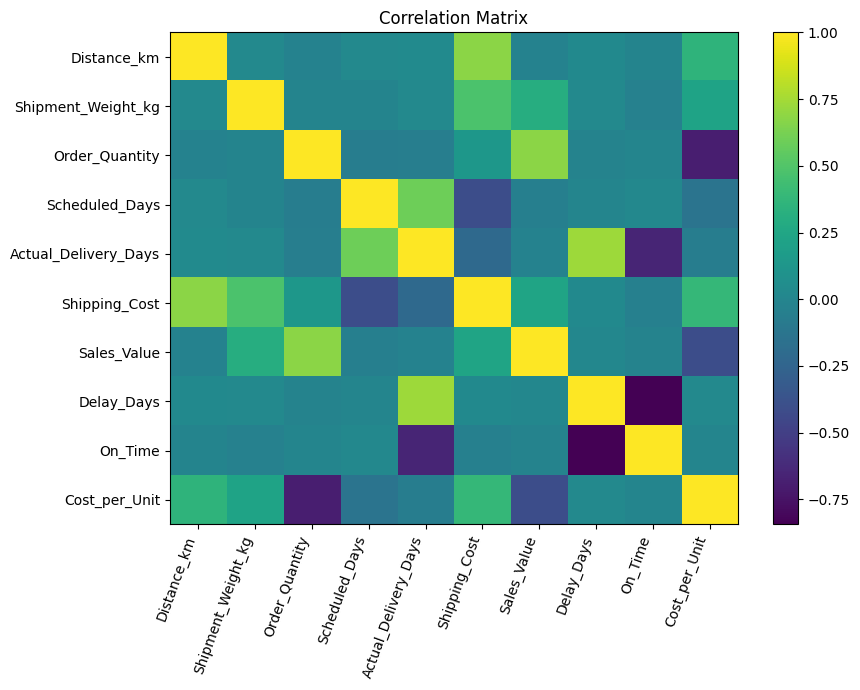

In [14]:
corr = df[num_cols].corr()
plt.figure(figsize=(9,7)); im = plt.imshow(corr, aspect='auto'); plt.colorbar(im)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=70, ha='right')
plt.yticks(range(len(corr.index)), corr.index); plt.title('Correlation Matrix')
plt.tight_layout(); plt.show()

## 10. Key Insights

- Overall on-time delivery is 52.2%.
- 47.8% of shipments experienced at least one day of delay.
- Distance is a major observed transportation-cost driver.
- Shipment weight also contributes to cost.
- Higher order quantities are associated with lower cost per unit.
- Regional and shipping-mode differences can guide targeted operational improvements.